In [ ]:
**PROJECT TITLE**
Marketing Funnel & Conversion Performance Analysis

Task 3 – Future Interns

This project analyzes marketing funnel data to identify conversion drop-offs, evaluate marketing channel performance, and recommend strategies to improve lead-to-customer conversion.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')

In [4]:
df = pd.read_csv("../data/marketing_funnel_dataset.csv")

df.head()

,Lead_ID,Lead_Source,Campaign,Impressions,Clicks,Leads,Qualified_Leads,Opportunities,Conversions,Marketing_Spend,Date
0,1,LinkedIn Ads,B2B Outreach,9270,942,137,105,67,32,379.95,2024-03-28
1,2,Facebook Ads,Retargeting,13636,1146,317,160,126,79,582.21,2024-01-21
2,3,Google Ads,Brand Awareness,3184,182,42,27,13,7,451.09,2024-01-15
3,4,Organic Search,B2B Outreach,2189,83,21,13,10,4,1747.89,2024-05-14
4,5,Google Ads,B2B Outreach,13080,468,157,131,94,39,375.81,2024-03-24


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Lead_ID          500 non-null    int64  
 1   Lead_Source      500 non-null    object 
 2   Campaign         500 non-null    object 
 3   Impressions      500 non-null    int64  
 4   Clicks           500 non-null    int64  
 5   Leads            500 non-null    int64  
 6   Qualified_Leads  500 non-null    int64  
 7   Opportunities    500 non-null    int64  
 8   Conversions      500 non-null    int64  
 9   Marketing_Spend  500 non-null    float64
 10  Date             500 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 43.1+ KB


In [8]:
df.describe()

,Lead_ID,Impressions,Clicks,Leads,Qualified_Leads,Opportunities,Conversions,Marketing_Spend
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,8539.936000,633.214000,143.456000,96.510000,56.284000,28.072000,1069.931660
std,144.481833,3827.337991,375.531527,98.808351,71.384686,44.885552,23.849957,512.640782
min,1.000000,2055.000000,70.000000,9.000000,5.000000,2.000000,1.000000,200.800000
25%,125.750000,5136.500000,324.750000,70.750000,45.000000,25.750000,11.750000,618.855000
50%,250.500000,8681.500000,550.500000,118.000000,77.500000,45.000000,21.000000,1035.225000
75%,375.250000,11891.500000,894.250000,191.000000,131.250000,74.000000,37.250000,1508.685000
max,500.000000,14996.000000,1718.000000,506.000000,414.000000,300.000000,140.000000,1994.050000


In [10]:
df.isnull().sum()

Lead_ID            0
Lead_Source        0
Campaign           0
Impressions        0
Clicks             0
Leads              0
Qualified_Leads    0
Opportunities      0
Conversions        0
Marketing_Spend    0
Date               0
dtype: int64

In [16]:
df['Date'] = pd.to_datetime(df['Date'])

In [18]:
funnel = df[['Impressions','Clicks','Leads','Qualified_Leads','Opportunities','Conversions']].sum()

funnel

Impressions        4269968
Clicks              316607
Leads                71728
Qualified_Leads      48255
Opportunities        28142
Conversions          14036
dtype: int64

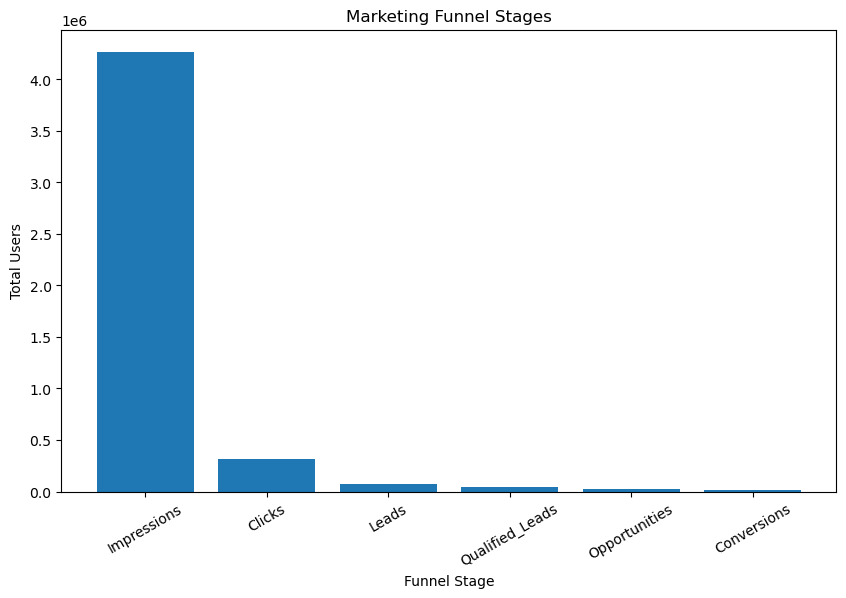

In [20]:
plt.figure(figsize=(10,6))

stages = funnel.index
values = funnel.values

plt.bar(stages, values)

plt.title("Marketing Funnel Stages")
plt.xlabel("Funnel Stage")
plt.ylabel("Total Users")

plt.xticks(rotation=30)

plt.savefig("../visuals/funnel_bar_chart.png")

plt.show()

In [22]:
conversion_rates = {
    "Impressions → Clicks": funnel['Clicks'] / funnel['Impressions'] * 100,
    "Clicks → Leads": funnel['Leads'] / funnel['Clicks'] * 100,
    "Leads → Qualified Leads": funnel['Qualified_Leads'] / funnel['Leads'] * 100,
    "Qualified Leads → Opportunities": funnel['Opportunities'] / funnel['Qualified_Leads'] * 100,
    "Opportunities → Conversions": funnel['Conversions'] / funnel['Opportunities'] * 100
}

conversion_rates

{'Impressions → Clicks': 7.41473940788315,
 'Clicks → Leads': 22.655216088083964,
 'Leads → Qualified Leads': 67.2749832701316,
 'Qualified Leads → Opportunities': 58.31934514558077,
 'Opportunities → Conversions': 49.87563072986995}

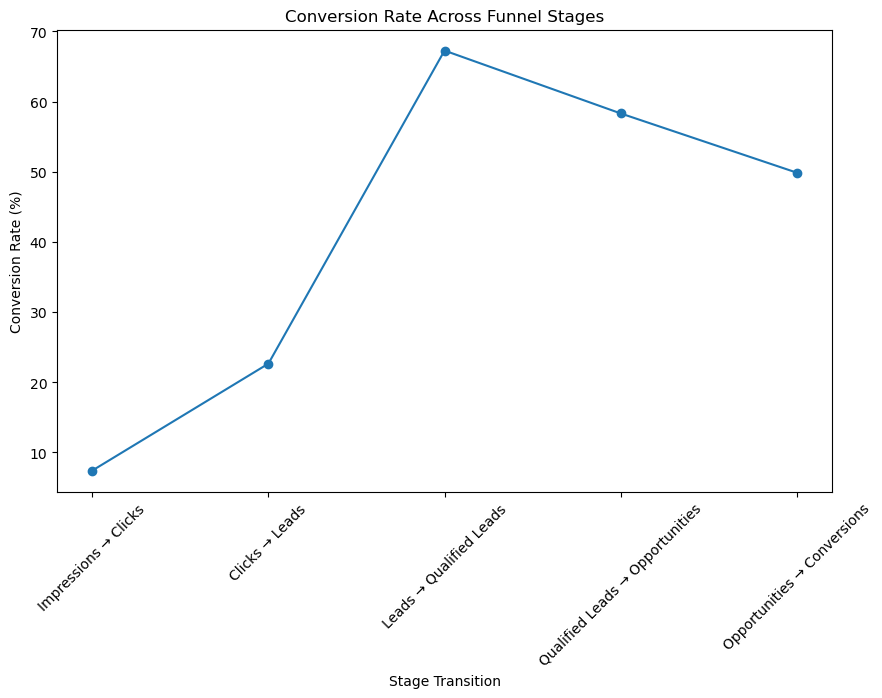

In [24]:
plt.figure(figsize=(10,6))

labels = list(conversion_rates.keys())
values = list(conversion_rates.values())

plt.plot(labels, values, marker='o')

plt.title("Conversion Rate Across Funnel Stages")
plt.xlabel("Stage Transition")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=45)

plt.savefig("../visuals/conversion_rate_line_chart.png")

plt.show()

In [26]:
source_performance = df.groupby("Lead_Source")[["Leads","Conversions"]].sum()

source_performance

,Leads,Conversions
Lead_Source,,
Email Marketing,11675,2485
Facebook Ads,14470,2922
Google Ads,16201,3074
LinkedIn Ads,15101,2809
Organic Search,14281,2746


In [28]:
source_performance["Conversion_Rate"] = (
    source_performance["Conversions"] / source_performance["Leads"]
) * 100

source_performance

,Leads,Conversions,Conversion_Rate
Lead_Source,,,
Email Marketing,11675,2485,21.284797
Facebook Ads,14470,2922,20.193504
Google Ads,16201,3074,18.974137
LinkedIn Ads,15101,2809,18.601417
Organic Search,14281,2746,19.228345


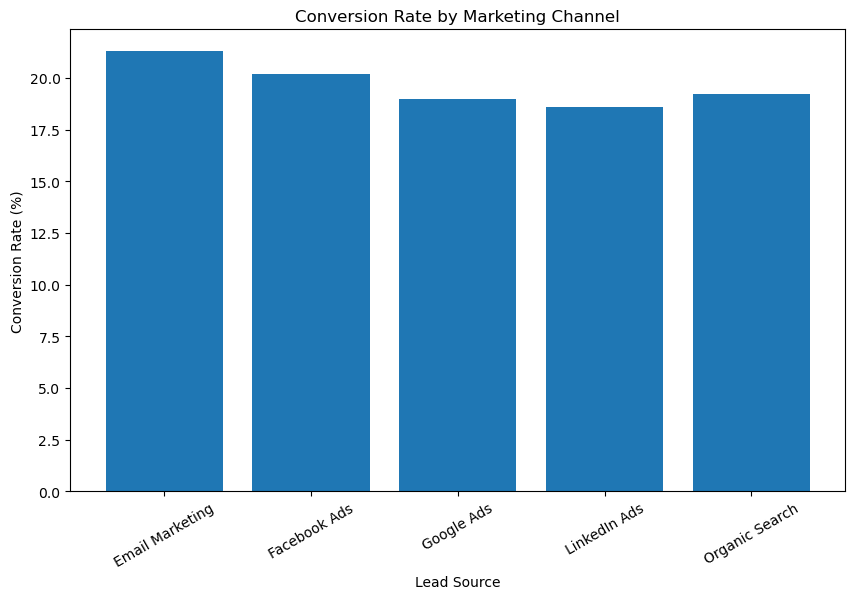

In [30]:
plt.figure(figsize=(10,6))

plt.bar(source_performance.index, source_performance["Conversion_Rate"])

plt.title("Conversion Rate by Marketing Channel")
plt.xlabel("Lead Source")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=30)

plt.savefig("../visuals/channel_conversion_rate.png")

plt.show()

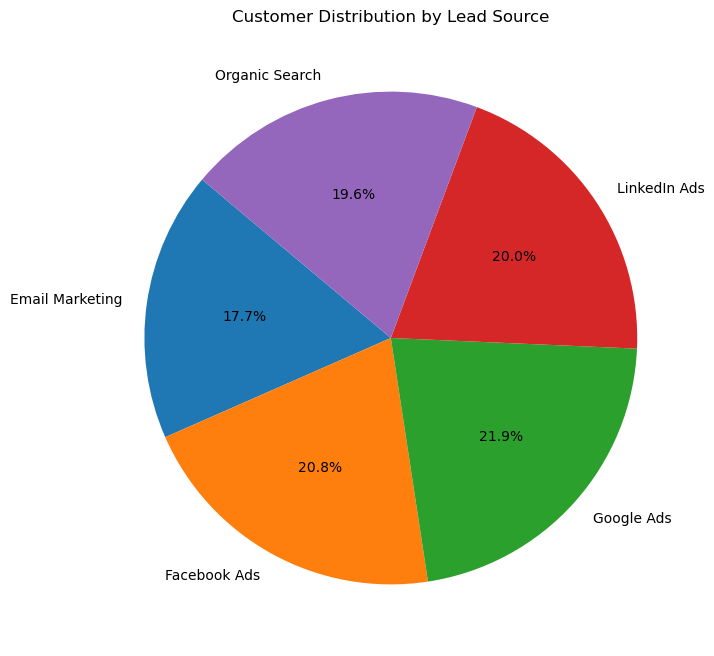

In [32]:
channel_conversions = df.groupby("Lead_Source")["Conversions"].sum()

plt.figure(figsize=(8,8))

plt.pie(channel_conversions,
        labels=channel_conversions.index,
        autopct="%1.1f%%",
        startangle=140)

plt.title("Customer Distribution by Lead Source")

plt.savefig("../visuals/channel_customer_share.png")

plt.show()

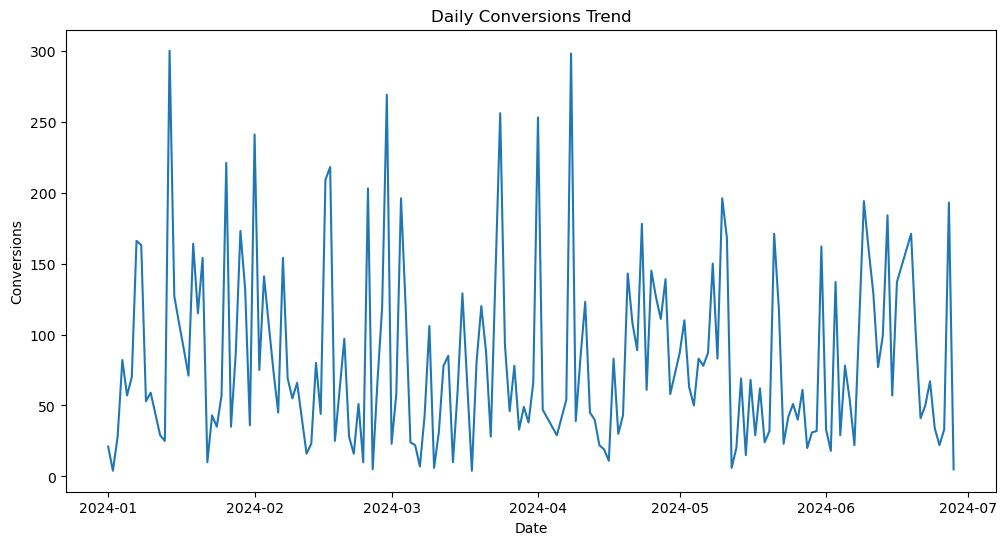

In [34]:
daily_conversions = df.groupby("Date")["Conversions"].sum()

plt.figure(figsize=(12,6))

plt.plot(daily_conversions.index, daily_conversions.values)

plt.title("Daily Conversions Trend")
plt.xlabel("Date")
plt.ylabel("Conversions")

plt.savefig("../visuals/daily_conversion_trend.png")

plt.show()

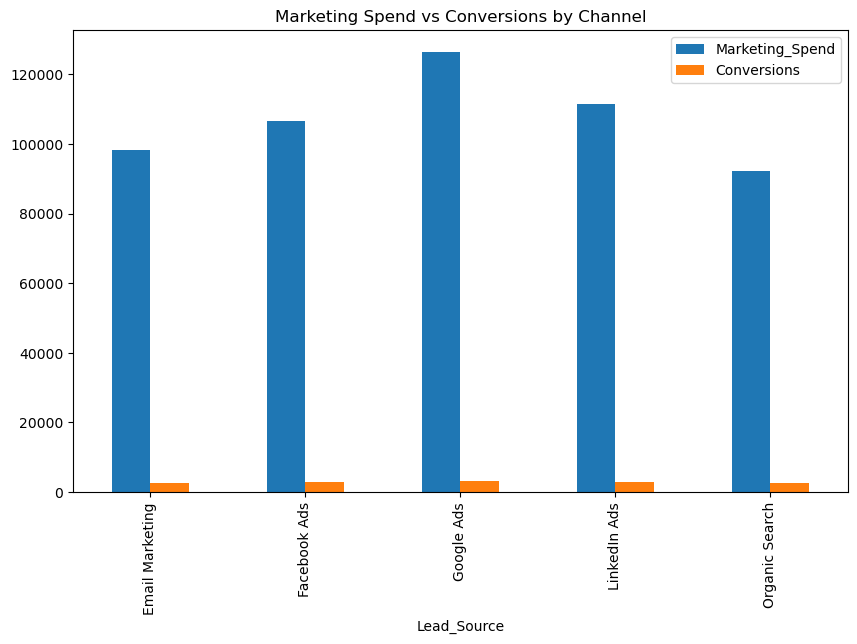

In [36]:
spend_vs_conv = df.groupby("Lead_Source")[["Marketing_Spend","Conversions"]].sum()

spend_vs_conv.plot(kind="bar", figsize=(10,6))

plt.title("Marketing Spend vs Conversions by Channel")

plt.savefig("../visuals/spend_vs_conversion.png")

plt.show()

In [ ]:
Key Insights:

1. The largest drop-off occurs between impressions and clicks, indicating low engagement with ads.
2. The conversion from leads to qualified leads shows moderate efficiency.
3. Some marketing channels generate more conversions compared to others.
4. Marketing spend does not always directly translate into higher conversions.
5. Certain periods show spikes in conversions, indicating successful campaigns.

In [ ]:
Business Recommendations:

1. Improve ad targeting and creative design to increase click-through rates.
2. Optimize landing pages to convert more visitors into leads.
3. Focus marketing budget on channels with higher conversion rates.
4. Improve lead nurturing strategies to convert qualified leads into opportunities.
5. Continuously monitor campaign performance using funnel metrics.

In [ ]:
Conclusion:

The marketing funnel analysis identified key drop-off stages and highlighted the performance of different marketing channels. By optimizing early funnel engagement and investing in high-performing channels, businesses can significantly improve their lead-to-customer conversion rates.

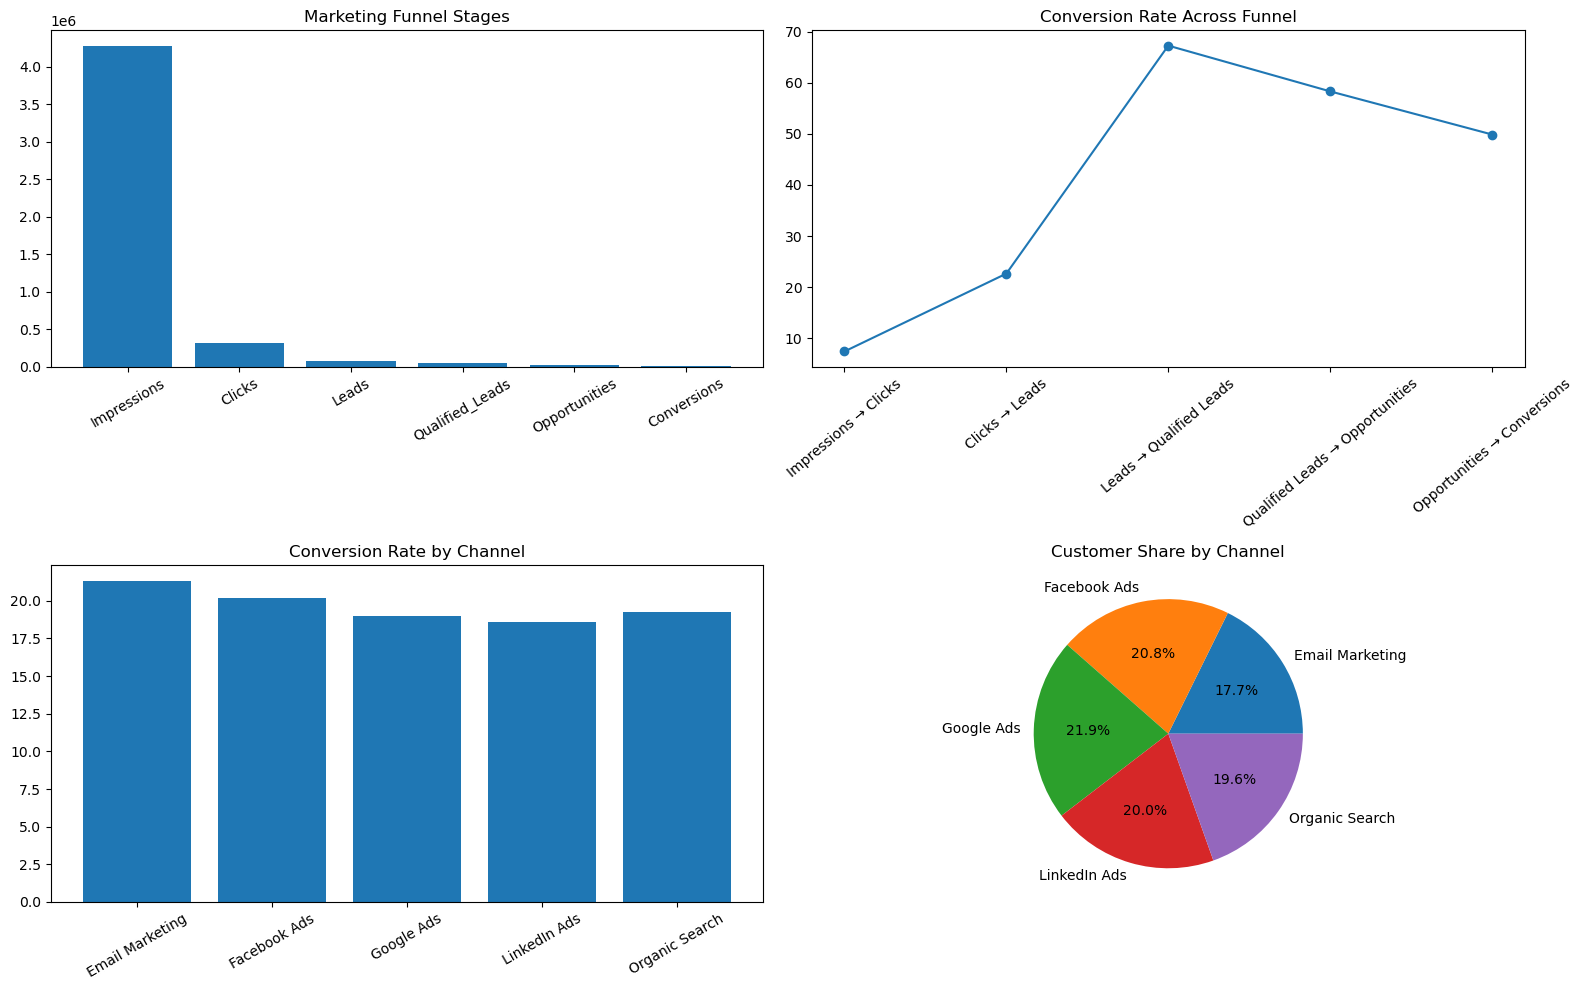

In [38]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16,10))

# ----------------------------
# Funnel Bar Chart
# ----------------------------
plt.subplot(2,2,1)

plt.bar(funnel.index, funnel.values)

plt.title("Marketing Funnel Stages")
plt.xticks(rotation=30)


# ----------------------------
# Conversion Rate Line Chart
# ----------------------------
plt.subplot(2,2,2)

plt.plot(list(conversion_rates.keys()),
         list(conversion_rates.values()),
         marker='o')

plt.title("Conversion Rate Across Funnel")
plt.xticks(rotation=40)


# ----------------------------
# Channel Conversion Bar Chart
# ----------------------------
plt.subplot(2,2,3)

plt.bar(source_performance.index,
        source_performance["Conversion_Rate"])

plt.title("Conversion Rate by Channel")
plt.xticks(rotation=30)


# ----------------------------
# Channel Share Pie Chart
# ----------------------------
plt.subplot(2,2,4)

plt.pie(channel_conversions,
        labels=channel_conversions.index,
        autopct='%1.1f%%')

plt.title("Customer Share by Channel")

plt.tight_layout()

plt.savefig("../dashboard/marketing_funnel_dashboard.png")

plt.show()